<a href="https://colab.research.google.com/github/clheow/Machine_Learning/blob/main/Prediksi_Keterlambatan_Penerbangan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd

In [57]:
# Load dataset
flights = pd.read_csv('/content/sample_data/flights.csv')

/tmp/ipykernel_2682/3186849024.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('/content/sample_data/flights.csv')


In [58]:
# DATA UNDERSTANDING

("=== Statistik Deskriptif ===")
display(flights.describe())

print("\n=== Contoh Data ===")
display(flights.head())

print("\n=== Informasi Dataset (Tabel) ===")
info_df = pd.DataFrame({
    "Column": flights.columns,
    "Non-Null Count": flights.notnull().sum(),
    "Data Type": flights.dtypes
})

info_df

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03



=== Contoh Data ===


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN



=== Informasi Dataset (Tabel) ===


,Column,Non-Null Count,Data Type
YEAR,YEAR,5819079,int64
MONTH,MONTH,5819079,int64
DAY,DAY,5819079,int64
DAY_OF_WEEK,DAY_OF_WEEK,5819079,int64
AIRLINE,AIRLINE,5819079,object
FLIGHT_NUMBER,FLIGHT_NUMBER,5819079,int64
TAIL_NUMBER,TAIL_NUMBER,5804358,object
ORIGIN_AIRPORT,ORIGIN_AIRPORT,5819079,object
DESTINATION_AIRPORT,DESTINATION_AIRPORT,5819079,object
SCHEDULED_DEPARTURE,SCHEDULED_DEPARTURE,5819079,int64


In [61]:
# DATA PREPROCESSING - SAMPLING

# Mengambil 50000 data secara random
flights = flights.sample(n=50000, random_state=42)

print("Jumlah data setelah sampling:", flights.shape)

# PILIH FITUR
data = flights[[
 'AIRLINE',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'DEPARTURE_DELAY',
 'DISTANCE',
 'AIR_TIME',
 'TAXI_OUT',
 'TAXI_IN',
 'SCHEDULED_DEPARTURE',
 'SCHEDULED_ARRIVAL',
 'DAY_OF_WEEK',
 'MONTH',
 'DAY',
 'ARRIVAL_DELAY'
]].copy()

# HANDLE MISSING VALUE
print("\nMissing values sebelum:")
print(data.isnull().sum())

data = data.dropna()

print("\nMissing values sesudah:")
print(data.isnull().sum())


# OUTLIER HANDLING
data['ARRIVAL_DELAY'] = data['ARRIVAL_DELAY'].clip(-100, 300)


# ENCODING DATA KATEGORICAL
from sklearn.preprocessing import LabelEncoder
import pandas as pd

for col in data.columns:

    data[col] = pd.to_numeric(data[col], errors='ignore')

    if data[col].dtype == 'object':
        data[col] = data[col].astype(str).str.strip()

        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])


# CEK HASIL
print("\nTipe data setelah preprocessing:")
print(data.dtypes)

print("\nContoh data:")
print(data.head())

Jumlah data setelah sampling: (50000, 31)

Missing values sebelum:
AIRLINE                  0
ORIGIN_AIRPORT           0
DESTINATION_AIRPORT      0
DEPARTURE_DELAY        743
DISTANCE                 0
AIR_TIME               896
TAXI_OUT               776
TAXI_IN                803
SCHEDULED_DEPARTURE      0
SCHEDULED_ARRIVAL        0
DAY_OF_WEEK              0
MONTH                    0
DAY                      0
ARRIVAL_DELAY          896
dtype: int64

Missing values sesudah:
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
DEPARTURE_DELAY        0
DISTANCE               0
AIR_TIME               0
TAXI_OUT               0
TAXI_IN                0
SCHEDULED_DEPARTURE    0
SCHEDULED_ARRIVAL      0
DAY_OF_WEEK            0
MONTH                  0
DAY                    0
ARRIVAL_DELAY          0
dtype: int64


/tmp/ipykernel_2682/1061551703.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col], errors='ignore')
/tmp/ipykernel_2682/1061551703.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col], errors='ignore')



Tipe data setelah preprocessing:
AIRLINE                  int64
ORIGIN_AIRPORT           int64
DESTINATION_AIRPORT      int64
DEPARTURE_DELAY        float64
DISTANCE                 int64
AIR_TIME               float64
TAXI_OUT               float64
TAXI_IN                float64
SCHEDULED_DEPARTURE      int64
SCHEDULED_ARRIVAL        int64
DAY_OF_WEEK              int64
MONTH                    int64
DAY                      int64
ARRIVAL_DELAY          float64
dtype: object

Contoh data:
         AIRLINE  ORIGIN_AIRPORT  DESTINATION_AIRPORT  DEPARTURE_DELAY  \
2355765       13             518                  404              4.0   
3710130        3             257                  373             70.0   
4204197        3             517                  449             -7.0   
3325267        0             488                  297             -5.0   
5816276       13             318                  444             -2.0   

         DISTANCE  AIR_TIME  TAXI_OUT  TAXI_IN  SCHEDULED_D

/tmp/ipykernel_2682/1061551703.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col], errors='ignore')
/tmp/ipykernel_2682/1061551703.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data[col] = pd.to_numeric(data[col], errors='ignore')


In [62]:
# FEATURE & TARGET

X = data.drop(columns=['ARRIVAL_DELAY'])
y = data['ARRIVAL_DELAY']

In [63]:
# NORMALISASI
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)


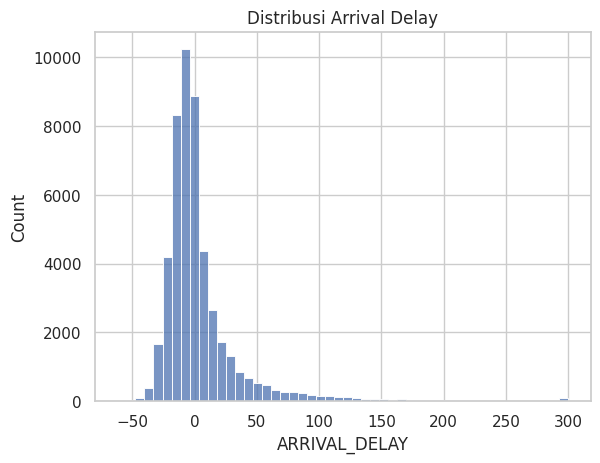

In [64]:
# EDA (VISUALISASI)

import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi delay
plt.figure()
sns.histplot(data['ARRIVAL_DELAY'], bins=50)
plt.title("Distribusi Arrival Delay")
plt.show()


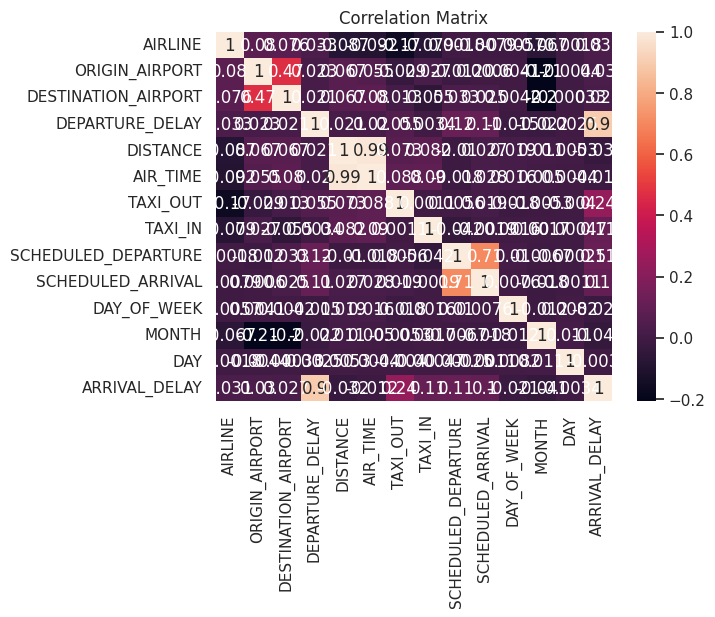

In [65]:
plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

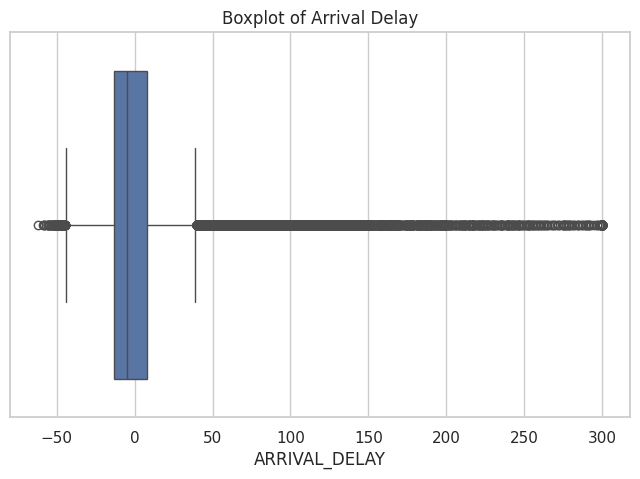

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=data['ARRIVAL_DELAY'])
plt.title("Boxplot of Arrival Delay")
plt.show()

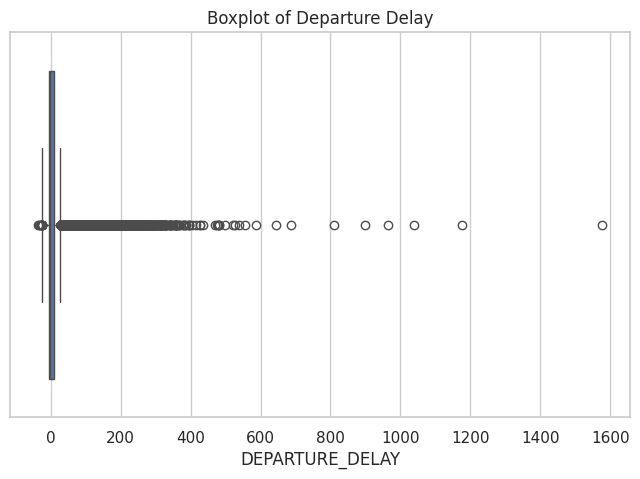

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data['DEPARTURE_DELAY'])
plt.title("Boxplot of Departure Delay")
plt.show()

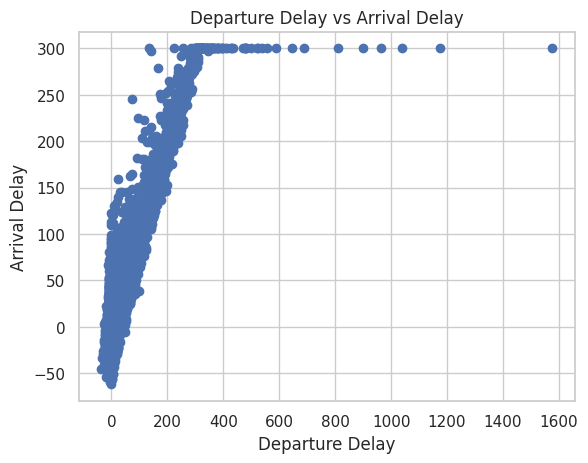

In [67]:
plt.figure()
plt.scatter(data['DEPARTURE_DELAY'], data['ARRIVAL_DELAY'])
plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay")
plt.ylabel("Arrival Delay")
plt.show()

In [68]:
# FUNCTION MODEL

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    return r2

In [70]:
#HYPERPARAMETER TUNING & EVALUASI

from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

def run_experiment(test_size):

    print(f"\n==============================")
    print(f"SPLIT {int((1-test_size)*100)}:{int(test_size*100)}")
    print(f"==============================")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42)

    results = {}

    # =========================
    # 1. Gradient Boosting
    # =========================
    gb_params = {
        'n_estimators': [50,100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }

    gb_grid = GridSearchCV(GradientBoostingRegressor(), gb_params, cv=2, n_jobs=-1)
    gb_grid.fit(X_train, y_train)

    print("Best GB Params:", gb_grid.best_params_)
    results["Gradient Boosting"] = evaluate_model(gb_grid.best_estimator_, X_test, y_test, "Gradient Boosting")

    # =========================
    # 2. KNN
    # =========================
    knn_params = {
        'n_neighbors': [3,5,7],
        'weights': ['uniform','distance']
    }

    knn_grid = GridSearchCV(KNeighborsRegressor(), knn_params, cv=2, n_jobs=-1)
    knn_grid.fit(X_train, y_train)

    print("Best KNN Params:", knn_grid.best_params_)
    results["KNN"] = evaluate_model(knn_grid.best_estimator_, X_test, y_test, "KNN")

    # =========================
    # 3. Random Forest
    # =========================
    rf_params = {
        'n_estimators': [50,100],
        'max_depth': [5, 10, None]
    }

    rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=2, n_jobs=-1)
    rf_grid.fit(X_train, y_train)

    print("Best RF Params:", rf_grid.best_params_)
    results["Random Forest"] = evaluate_model(rf_grid.best_estimator_, X_test, y_test, "Random Forest")

    return results

In [71]:
# MODEL EVALUATION

results = []

results.append(run_experiment(0.3))  # 70:30
results.append(run_experiment(0.2))  # 80:20
results.append(run_experiment(0.1))  # 90:10


SPLIT 70:30
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Gradient Boosting
MAE  : 6.3313
MSE  : 73.2929
RMSE : 8.5611
R2   : 0.9418
Best KNN Params: {'n_neighbors': 7, 'weights': 'distance'}

KNN
MAE  : 9.9585
MSE  : 188.3274
RMSE : 13.7232
R2   : 0.8504
Best RF Params: {'max_depth': None, 'n_estimators': 100}

Random Forest
MAE  : 6.7336
MSE  : 86.6942
RMSE : 9.3110
R2   : 0.9312

SPLIT 80:20
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Gradient Boosting
MAE  : 6.3132
MSE  : 74.2331
RMSE : 8.6159
R2   : 0.9403
Best KNN Params: {'n_neighbors': 7, 'weights': 'distance'}

KNN
MAE  : 9.8088
MSE  : 184.1672
RMSE : 13.5708
R2   : 0.8520
Best RF Params: {'max_depth': None, 'n_estimators': 100}

Random Forest
MAE  : 6.7381
MSE  : 89.1634
RMSE : 9.4426
R2   : 0.9283

SPLIT 90:10
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Gradient Boosting
MAE  : 6.3797
MSE  : 77.4479
RMSE : 8.8004
R2   : 0.9390
B

In [72]:
df_results = pd.DataFrame(results, index=["70:30","80:20","90:10"])

df_results = df_results.reset_index().rename(columns={"index": "Split"})

df_results = pd.melt(
    df_results,
    id_vars="Split",
    var_name="Model",
    value_name="Test R2"
)

(df_results.head(9))

,Split,Model,Test R2
0,70:30,Gradient Boosting,0.941798
1,80:20,Gradient Boosting,0.940325
2,90:10,Gradient Boosting,0.939014
3,70:30,KNN,0.850450
4,80:20,KNN,0.851951
5,90:10,KNN,0.846539
6,70:30,Random Forest,0.931156
7,80:20,Random Forest,0.928323
8,90:10,Random Forest,0.926719


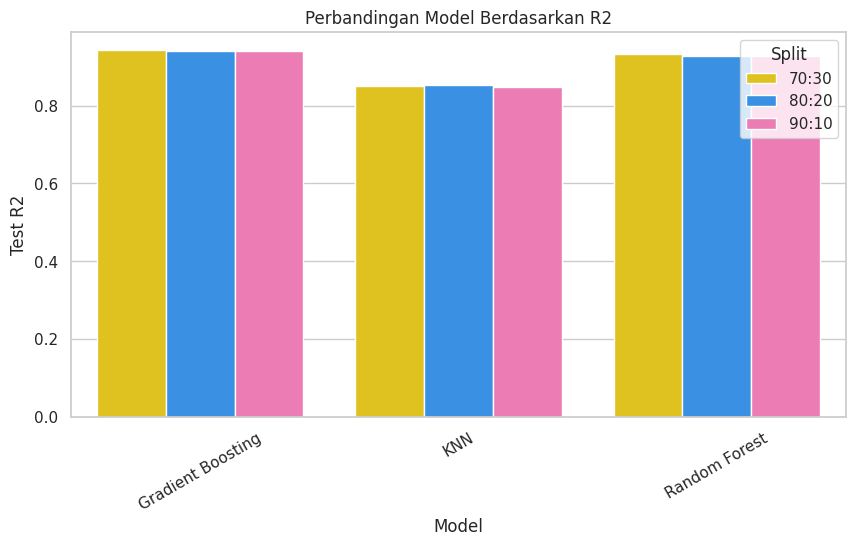

In [73]:
# MODEL COMPARISON
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_results,
    x="Model",
    y="Test R2",
    hue="Split",
    palette=["#FFD700", "#1E90FF", "#FF69B4"]
)

plt.title("Perbandingan Model Berdasarkan R2")
plt.xticks(rotation=30)

plt.show()

In [75]:
# INFERENCE

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# train model
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)

model.fit(X_train, y_train)

# DATA BARU
data_baru = pd.DataFrame([
    {
        'AIRLINE': 1,
        'ORIGIN_AIRPORT': 23,
        'DESTINATION_AIRPORT': 45,
        'DEPARTURE_DELAY': 10,
        'DISTANCE': 500,
        'AIR_TIME': 120,
        'TAXI_OUT': 5,
        'TAXI_IN': 3,
        'SCHEDULED_DEPARTURE': 800,
        'SCHEDULED_ARRIVAL': 1000,
        'DAY_OF_WEEK': 2,
        'MONTH': 7,
        'DAY': 15
    },
    {
        'AIRLINE': 2,
        'ORIGIN_AIRPORT': 10,
        'DESTINATION_AIRPORT': 30,
        'DEPARTURE_DELAY': 20,
        'DISTANCE': 700,
        'AIR_TIME': 150,
        'TAXI_OUT': 8,
        'TAXI_IN': 4,
        'SCHEDULED_DEPARTURE': 900,
        'SCHEDULED_ARRIVAL': 1200,
        'DAY_OF_WEEK': 5,
        'MONTH': 12,
        'DAY': 20
    }
])

prediksi = model.predict(data_baru)

for i, val in enumerate(prediksi, 1):
    print(f"Data {i}: {val}")

Data 1: 313.780939286583
Data 2: 316.3355753499673


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(
